
Metric               Strategy    Buy & Hold
------------------------------------------
Total Return          83.25%      248.64%
Sharpe Ratio            0.442         0.639
Max Drawdown         -70.90%      -75.95%
Total Trades               56



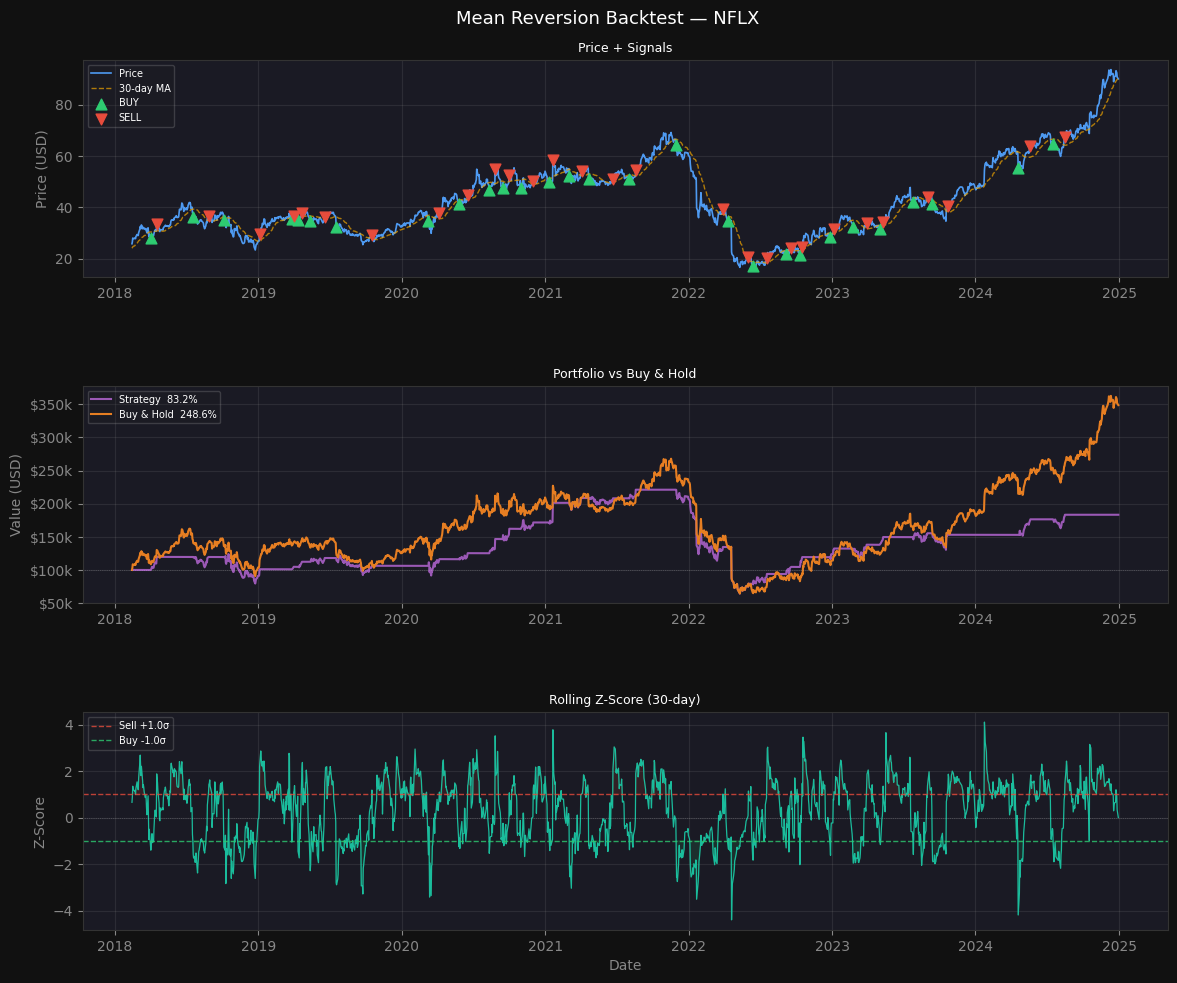

Chart saved → backtest_results.png


In [2]:
# Mean Reversion Backtest — NFLX
# Strategy: BUY when z-score < -1 (oversold), SELL when z-score > +1 (overbought)
!pip install yfinance pandas numpy matplotlib

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf

warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────────────────────
TICKER          = "NFLX"
START_DATE      = "2018-01-01"
END_DATE        = "2024-12-31"
INITIAL_CAPITAL = 100_000.0
WINDOW          = 30      # rolling z-score lookback (days)
Z_BUY           = -1.0   # enter when price is 1σ below mean
Z_SELL          = +1.0   # exit  when price is 1σ above mean
COST            = 0.001  # 0.1% transaction cost per trade

# ── DATA ──────────────────────────────────────────────────────────────────────
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)

df = raw[["Close"]].rename(columns={"Close": "Price"})

# ── Z-SCORE ───────────────────────────────────────────────────────────────────
df["Mean"]    = df["Price"].rolling(WINDOW).mean()
df["Z_Score"] = (df["Price"] - df["Mean"]) / df["Price"].rolling(WINDOW).std()
df.dropna(inplace=True)

# ── SIGNALS & POSITIONS ───────────────────────────────────────────────────────
position, positions, buys, sells = 0, [], [], []

for date, row in df.iterrows():
    if row["Z_Score"] < Z_BUY and position == 0:
        position = 1
        buys.append(date)
    elif row["Z_Score"] > Z_SELL and position == 1:
        position = 0
        sells.append(date)
    positions.append(position)

df["Position"] = positions

# ── BACKTEST ──────────────────────────────────────────────────────────────────
df["Mkt_Ret"]   = df["Price"].pct_change()
df["Strat_Ret"] = df["Mkt_Ret"] * df["Position"].shift(1)
df["Strat_Ret"] -= df["Position"].diff().abs() * COST   # transaction cost

df["Strategy"] = INITIAL_CAPITAL * (1 + df["Strat_Ret"]).cumprod().fillna(1)
df["BuyHold"]  = INITIAL_CAPITAL * (1 + df["Mkt_Ret"]).cumprod().fillna(1)

# ── METRICS ───────────────────────────────────────────────────────────────────
def metrics(values, returns):
    total_ret = values.iloc[-1] / values.iloc[0] - 1
    sharpe    = returns.mean() / returns.std() * np.sqrt(252) if returns.std() else 0
    max_dd    = ((values - values.cummax()) / values.cummax()).min()
    return total_ret, sharpe, max_dd

s_ret, s_sharpe, s_dd = metrics(df["Strategy"], df["Strat_Ret"])
b_ret, b_sharpe, b_dd = metrics(df["BuyHold"],  df["Mkt_Ret"])
trades = len(buys) + len(sells)

print(f"\n{'Metric':<16} {'Strategy':>12}  {'Buy & Hold':>12}")
print("-" * 42)
print(f"{'Total Return':<16} {s_ret:>11.2%}  {b_ret:>11.2%}")
print(f"{'Sharpe Ratio':<16} {s_sharpe:>12.3f}  {b_sharpe:>12.3f}")
print(f"{'Max Drawdown':<16} {s_dd:>11.2%}  {b_dd:>11.2%}")
print(f"{'Total Trades':<16} {trades:>12}\n")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), facecolor="#111")
fig.suptitle(f"Mean Reversion Backtest — {TICKER}", color="white", fontsize=13)
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.5, top=0.93, bottom=0.06)

def style(ax):
    ax.set_facecolor("#1a1a24")
    ax.tick_params(colors="#888")
    ax.grid(True, alpha=0.12)
    for sp in ax.spines.values():
        sp.set_color("#333")

# Panel 1 — Price + signals
ax1 = fig.add_subplot(gs[0])
style(ax1)
ax1.plot(df.index, df["Price"], color="#4e9af1", lw=1.2, label="Price")
ax1.plot(df.index, df["Mean"],  color="#f0a500", lw=1.0, ls="--", alpha=0.7, label=f"{WINDOW}-day MA")
ax1.scatter(df.loc[buys,  "Price"].index, df.loc[buys,  "Price"], marker="^", color="#2ecc71", s=60, zorder=5, label="BUY")
ax1.scatter(df.loc[sells, "Price"].index, df.loc[sells, "Price"], marker="v", color="#e74c3c", s=60, zorder=5, label="SELL")
ax1.set_ylabel("Price (USD)", color="#888")
ax1.set_title("Price + Signals", color="white", fontsize=9)
ax1.legend(fontsize=7, framealpha=0.2, labelcolor="white", facecolor="#222")

# Panel 2 — Portfolio vs benchmark
ax2 = fig.add_subplot(gs[1])
style(ax2)
ax2.plot(df.index, df["Strategy"], color="#9b59b6", lw=1.5, label=f"Strategy  {s_ret:.1%}")
ax2.plot(df.index, df["BuyHold"],  color="#e67e22", lw=1.5, label=f"Buy & Hold  {b_ret:.1%}")
ax2.axhline(INITIAL_CAPITAL, color="white", lw=0.5, ls=":", alpha=0.3)
ax2.set_ylabel("Value (USD)", color="#888")
ax2.set_title("Portfolio vs Buy & Hold", color="white", fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
ax2.legend(fontsize=7, framealpha=0.2, labelcolor="white", facecolor="#222")

# Panel 3 — Z-score
ax3 = fig.add_subplot(gs[2])
style(ax3)
ax3.plot(df.index, df["Z_Score"], color="#1abc9c", lw=0.9)
ax3.axhline(Z_SELL, color="#e74c3c", lw=1.0, ls="--", alpha=0.8, label=f"Sell +{Z_SELL}σ")
ax3.axhline(Z_BUY,  color="#2ecc71", lw=1.0, ls="--", alpha=0.8, label=f"Buy {Z_BUY}σ")
ax3.axhline(0, color="white", lw=0.5, ls=":", alpha=0.3)
ax3.fill_between(df.index, df["Z_Score"], Z_SELL, where=(df["Z_Score"] > Z_SELL), color="#e74c3c", alpha=0.12)
ax3.fill_between(df.index, df["Z_Score"], Z_BUY,  where=(df["Z_Score"] < Z_BUY),  color="#2ecc71", alpha=0.12)
ax3.set_ylabel("Z-Score", color="#888")
ax3.set_xlabel("Date",    color="#888")
ax3.set_title(f"Rolling Z-Score ({WINDOW}-day)", color="white", fontsize=9)
ax3.legend(fontsize=7, framealpha=0.2, labelcolor="white", facecolor="#222")

plt.savefig("backtest_results.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Chart saved → backtest_results.png")